# Libraries 

In [24]:
import os
import pandas as pd
import numpy as np
from skimage.io import imread, imsave
import matplotlib.pyplot as plt
import cv2
import zipfile
import shutil
import math
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)

# Useful functions 

In [25]:
def resize_image(img, scale_percent):
    """
    Resizes an image to a given percentage of the original.

    Parameters
    ----------
    img : numpy darray
        Image to resize
    scale_percent : float
        Scaling percent for resizing

    Returns
    -------
    resized : numpy darray
        The resized image

    """

    width = int(img.shape[1] * scale_percent / 100)
    height = int(img.shape[0] * scale_percent / 100)

    if scale_percent <= 100:
        resized = cv2.resize(img, (width, height),
                             interpolation=cv2.INTER_AREA)
    else:
        resized = cv2.resize(img, (width, height),
                             interpolation=cv2.INTER_LINEAR)

    return(resized)


def invert_grayscale(img):
    """ Inverts the grayscale of an image. """

    inverted_img = 255 - img

    return(inverted_img)

In [39]:
def plot_track_and_vignettes_APERO(df_particles, disp_step, save_path = None):
    """
    Plots the track of particles and side-by-side vignettes of each particle.

    Parameters
    ----------
    df_particles : pandas.DataFrame
        DataFrame containing particle data. Each row corresponds to a particle with 
        columns for the x and y coordinates, track_id, and the particle orientation.
    deployment : str
        Name of the deployment of the project.
    depth : str
        Depth of the deployment.
    """
    try:    
        # Initialize the figure size and layout
        ncols = 4 + math.ceil((len(df_particles)/3) / 4)
        
        #print('ncols: ', ncols)
        nrows = 4
        if ncols >= 6:
            fig_width = 16
        elif ncols == 5:
            fig_width = 14
        elif ncols == 4:
            fig_width = 12
        elif ncols == 3:
            fig_width = 10
        elif ncols == 2:
            fig_width = 8
        elif ncols == 1:
            fig_width = 7
        #print('fig width: ', fig_width)
        fig = plt.figure(figsize=(fig_width, 6), constrained_layout=True)
        gs = fig.add_gridspec(nrows, ncols)
        #print('gs: ', gs)
        
        # Plotting the track in general
        ax1 = fig.add_subplot(gs[0:5, :3])
        #print('ax for track: ', ax1)
            
        #ax1.plot(df_particles['coord_x'], df_particles['coord_y'], color = 'black', linestyle='-', linewidth = 1.5, markersize = 5, marker='o')
        
        x = df_particles['coord_x']
        y = df_particles['coord_y']
        
        # Indices for every 3rd point starting at index 0
        idx_black = np.arange(0, len(df_particles), disp_step)
        
        # Indices for all other points
        idx_white = np.array([i for i in range(len(df_particles)) if i not in idx_black])
        
        # Plot white filled markers with black edges first
        ax1.scatter(x.iloc[idx_white], y.iloc[idx_white],
                    marker='o',
                    facecolors='white',    # fill color
                    edgecolors='black',    # marker border color
                    s=25,                  # marker size (you can adjust)
                    linewidths=1)
        
        # Plot black filled markers for every third point
        ax1.scatter(x.iloc[idx_black], y.iloc[idx_black],
                    marker='o',
                    color='black',         # filled marker
                    s=40)
        
        # Highlight the first point in green
        ax1.plot(
            df_particles['coord_x'].iloc[0],
            df_particles['coord_y'].iloc[0],
            marker='o',
            color='green',
            markersize=7,
            linestyle='None',  # No line
            label = r'$t_0$'
                )
        
        # Highlight the last point in red
        ax1.plot(
            df_particles['coord_x'].iloc[-1],
            df_particles['coord_y'].iloc[-1],
            marker='o',
            color='red',
            markersize=7,
            linestyle='None',
            label = r'$t_f$'
                )   
        
        raw_speed = df_particles['vertical_speed'].iloc[0] # extract raw vertical speed
        corrected_speed = df_particles['corrected_by_poly'].iloc[0] # extract corrected vertical speed 
        orientation_raw = df_particles['orientation_raw'].iloc[0] # extract raw orientation
        orientation_corrected = df_particles['orientation_corrected'].iloc[0] # extract orientation after correction 
        mean_esd = df_particles['esd_um'].mean()
        
        ax1.set_xlim(0, 2464)
        ax1.set_ylim(0, 2056) 
         
        ax1.invert_yaxis()
        
        #ax1.set_title(f"{df_particles['track_id'].iloc[0]}, Speed: {round(speed)} m/d, Orientation: {orientation}", fontsize=12)
        fig.suptitle(
            r"$\bf{ID:}$ " + f"{df_particles['track_id'].iloc[0]}, "
            r"$\bf{ESD:}$ " + f"{round(mean_esd)} µm, "
            r"$\bf{Raw\ VS:}$ " + f"{round(raw_speed)} m·d$^{{-1}}$, "
            r"$\bf{Corrected\ VS:}$ " + f"{round(corrected_speed)} m·d$^{{-1}}$, "
            r"$\bf{Orientation:}$ " + f"{orientation_corrected}",
            fontsize=12,
            color='black',
            x=0.01,            # shift very close to left edge (0.0 = extreme left)
            ha='left'
            #fontfamily='serif'
                    )
    
        # Scale bar
        bar_length = 137  # in image pixel units (= 1 cm)
        bar_y = 2000
        bar_x = 75  
    
        ax1.plot([bar_x, bar_x + bar_length], [bar_y, bar_y], color='grey', linewidth=2, solid_capstyle='butt')
        ax1.plot([bar_x, bar_x], [bar_y, bar_y - bar_length], color='grey', linewidth=2, solid_capstyle='butt')

        size = 12
        
        #ax1.text(0.08, 0.06, '1 cm', color='grey', 
         #        fontsize=size, ha='center', va='center', fontweight = 'bold',
          #       alpha = 1, transform=ax1.transAxes)
        
        
        ax1.set_xlabel('Horizontal axis (pixels)', size=size)
        ax1.set_ylabel('Vertical axis (pixels)', size=size)

        # Ticks and labels
        l, w, pad = 4, 2, 4
        ax1.tick_params(axis='y', labelsize=size, pad=pad, length=l, width=w)
        ax1.tick_params(axis='x', labelsize=size, pad=pad, length=l, width=w)
        
        for spine in ax1.spines.values():
            spine.set_linewidth(2)
        
        legend1 = ax1.legend(loc='upper left', bbox_to_anchor=(0, 1),
          labelspacing=0.5, fontsize=size,
          markerscale=1, handletextpad=0.5, borderpad=1,
          edgecolor='black', frameon=True, framealpha=1,
          fancybox=True, shadow=True, ncol=1) # bbox_to_anchor=(0.6, 0.05)
        
        legend1.get_frame().set_linewidth(1.5)
        
        # Plotting vignettes side by side
        ct_col, ct_row = 3, 4  # Start positions for the vignettes grid
        vignette_axes = []
        indices = [0] + list(range(disp_step, len(df_particles) - 1, disp_step)) + [len(df_particles) - 1]
        for i, row in df_particles.iloc[indices].iterrows():
            
            ncol = math.trunc(ct_col)
            
            ct_col += 0.25
            nrow = ct_row % 4
            ct_row += 1
    
            # Reading the image corresponding to this particle
            img = imread(row['filename'])         
                
            
            # Calculate window for cropping around particle
            esd_px = row['esd_px']  # Particle size in pixels
            window = esd_px + 4
            right = min(int(row['coord_x'] + window), 2464)  # Adjust image dimensions
            left = max(0, int(row['coord_x'] - window))
            top = max(0, int(row['coord_y'] - window))
            bott = min(int(row['coord_y'] + window), 2056)  # Adjust image dimensions
            
            # Crop the image
            crop = img[top:bott, left:right]
            
            # Convert crop to dimensions in µm (assuming 73 µm per pixel)
            width, height = crop.shape[1] * 73 / 1000, crop.shape[0] * 73 / 1000
            
            # Invert grayscale and resize image for better visualization
            crop = invert_grayscale(resize_image(crop, 750))
    
            # Add the cropped particle image to the grid
            ax = fig.add_subplot(gs[nrow, ncol])
            vignette_axes.append(ax)
            #print('ax for vig: ', ax)
            ax.imshow(crop, cmap='gray', extent=[0, width, height, 0], vmin=0, vmax=255)

            step_num = row['step_num']
            #ax.set_title(f"r'$t_{step_num}$' | (µm)", fontsize=6)
            ax.set_title(f"{step_num} | (mm)", fontsize=8)
                    # Ticks and labels
            
            l, w, pad = 4, 1.5, 4

            ax.tick_params(axis="x", labelsize=8, pad=pad, length=l, width=w)
            ax.tick_params(axis="y", labelsize=8, pad=pad, length=l, width=w)
            
            for spine in ax.spines.values():
                spine.set_linewidth(1.5)

            
        for spine in vignette_axes[0].spines.values():
            spine.set_linewidth(2)
            spine.set_edgecolor('green')

        for spine in vignette_axes[-1].spines.values():
            spine.set_linewidth(2)
            spine.set_edgecolor('red')
                
        # Tighten layout and save the figure
        plt.tight_layout(h_pad=0.2)
        
        if save_path:
            try:
                filename = f"{save_path}/{df_particles['track_id'].iloc[0]}_{orientation_corrected}.png"
                plt.savefig(filename, dpi=300)
                plt.show()
                plt.close()
            except Exception as e:
                print(f"Could not save figure: {e}")        
        
        plt.show()
         
                
    except Exception as e:
        print(f"Could not create the figure: {e}")  

# Import selected tracks from APERO cruise

In [27]:
APERO_tracks = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/APERO_selected_tracks_by_interquartile_poly_no_living.csv')
APERO_tracks = APERO_tracks.drop(columns =  ['Unnamed: 0'])
APERO_tracks['orientation_raw'] = np.where(APERO_tracks['vertical_speed'] < 0, 'asc', 'desc')
APERO_tracks['orientation_corrected'] = np.where(APERO_tracks['corrected_by_poly'] < 0, 'asc', 'desc')
APERO_tracks = APERO_tracks[['track_id', 'orientation_corrected', 'orientation_raw', 'vertical_speed', 'corrected_by_poly', 'esd_um']]
APERO_tracks

,track_id,orientation_corrected,orientation_raw,vertical_speed,corrected_by_poly,esd_um
0,APERO_C1_20230611-002816-1-916,desc,desc,27.067691,75.065237,246.547642
1,APERO_C1_20230611-002829-1-1435,desc,desc,31.555337,78.591289,1035.906803
2,APERO_C1_20230611-002834-1-1578,desc,desc,51.631967,98.552216,108.968921
3,APERO_C1_20230611-002907-2-2931,desc,desc,40.011558,81.530760,136.415389
4,APERO_C1_20230611-002918-1-3368,desc,desc,48.514431,89.085797,124.092221
...,...,...,...,...,...,...
791,APERO_C5_20230713-043248-1-8413,desc,desc,149.314402,62.452042,859.596554
792,APERO_C5_20230713-043301-1-8717,desc,desc,169.000999,74.398845,239.397542
793,APERO_C5_20230713-043322-1-9208,desc,desc,171.007026,64.130513,402.057780
794,APERO_C5_20230713-043431-1-11126,asc,desc,84.461913,-60.180652,165.521745


# Import the dataframe with informations on particle at each step of each track

In [28]:
all_df = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/APERO_tracks_all.csv')
all_df['datetime'] = all_df['datetime'].str.replace('.000', '') # remove the .000 part from the datetime value
all_df['datetime'] = all_df['datetime'].str.replace('.500', '') # same for the .500
all_df['datetime'] = pd.to_datetime(all_df['datetime']) # convert to datetime
APERO_all_df = all_df.drop(['vertical_speed', 'orientation'], axis=1) # drop vertical_speed and orientation columns because they are already in the summary dataframe
APERO_all_df = APERO_all_df[['track_id', 'sequence', 'coord_x', 'coord_y', 'esd_px', 'filename']]
APERO_all_df

,track_id,sequence,coord_x,coord_y,esd_px,filename
0,APERO_C1_20230610-192806-1-422,20230610-192734,448.533333,156.400000,4.370194,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
1,APERO_C1_20230610-192806-1-422,20230610-192734,452.272727,137.454545,3.742410,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
2,APERO_C1_20230610-192806-1-422,20230610-192734,451.928571,119.785714,4.222008,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
3,APERO_C1_20230610-192806-1-422,20230610-192734,449.300000,104.400000,3.568248,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
4,APERO_C1_20230610-192806-1-422,20230610-192734,445.923077,93.153846,4.068429,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
...,...,...,...,...,...,...
1288413,APERO_C5_20230713-051433-1-11419,20230713-050803,368.439655,410.905172,12.153016,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
1288414,APERO_C5_20230713-051433-1-11419,20230713-050803,355.121739,411.495652,12.100518,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
1288415,APERO_C5_20230713-051433-1-11419,20230713-050803,341.633094,411.122302,13.303394,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
1288416,APERO_C5_20230713-051433-1-11419,20230713-050803,335.431655,410.395683,13.303394,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...


# Merge both dataframe 

In [29]:
APERO_tracks = pd.merge(APERO_tracks, APERO_all_df, on = 'track_id')
APERO_tracks = APERO_tracks[APERO_tracks['track_id'].str.contains('C5', na=False)]
APERO_tracks

,track_id,orientation_corrected,orientation_raw,vertical_speed,corrected_by_poly,esd_um,sequence,coord_x,coord_y,esd_px,filename
8564,APERO_C5_20230709-021101-1-1112,desc,desc,109.902951,359.66253,515.762066,20230709-021011,1350.562500,10.625000,4.513517,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
8565,APERO_C5_20230709-021101-1-1112,desc,desc,109.902951,359.66253,515.762066,20230709-021011,1346.769231,20.769231,4.068429,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
8566,APERO_C5_20230709-021101-1-1112,desc,desc,109.902951,359.66253,515.762066,20230709-021011,1358.083333,48.833333,3.908820,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
8567,APERO_C5_20230709-021101-1-1112,desc,desc,109.902951,359.66253,515.762066,20230709-021011,1356.600000,60.200000,2.523133,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
8568,APERO_C5_20230709-021101-1-1112,desc,desc,109.902951,359.66253,515.762066,20230709-021011,1354.737079,80.292135,23.803185,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
...,...,...,...,...,...,...,...,...,...,...,...
10953,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.53279,638.178689,20230713-042803,274.666667,1847.727273,9.166996,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
10954,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.53279,638.178689,20230713-042803,271.535211,1893.478873,9.507892,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
10955,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.53279,638.178689,20230713-042803,268.144737,1941.328947,9.836982,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
10956,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.53279,638.178689,20230713-042803,264.507042,1989.802817,9.507892,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...


# Modify the path in filename column to fit with the folder where the images will be pasted

In [30]:
APERO_tracks['filename'] = APERO_tracks['filename'].str.replace('/these_alex/Analysis/APERO/TZEX/cycle_5/raw/', '/these_alex/Papers/Rising_stars/Track_plots/copy_raw/')
APERO_tracks['filename'].iloc[0]

'/home/aaccardo/these_alex/Papers/Rising_stars/Track_plots/copy_raw/20230709-021011/1/20230709-021101-1.png'

# Select only particles with esd > 600 µm

In [31]:
APERO_tracks = APERO_tracks[APERO_tracks['esd_um'] >= 600]
APERO_tracks

,track_id,orientation_corrected,orientation_raw,vertical_speed,corrected_by_poly,esd_um,sequence,coord_x,coord_y,esd_px,filename
8685,APERO_C5_20230711-005229-1-2548,desc,desc,115.108079,70.984823,787.072136,20230711-004949,882.605263,582.105263,6.955796,/home/aaccardo/these_alex/Papers/Rising_stars/...
8686,APERO_C5_20230711-005229-1-2548,desc,desc,115.108079,70.984823,787.072136,20230711-004949,878.038095,603.133333,11.562446,/home/aaccardo/these_alex/Papers/Rising_stars/...
8687,APERO_C5_20230711-005229-1-2548,desc,desc,115.108079,70.984823,787.072136,20230711-004949,873.840909,625.053030,12.964090,/home/aaccardo/these_alex/Papers/Rising_stars/...
8688,APERO_C5_20230711-005229-1-2548,desc,desc,115.108079,70.984823,787.072136,20230711-004949,869.218487,644.436975,12.309163,/home/aaccardo/these_alex/Papers/Rising_stars/...
8689,APERO_C5_20230711-005229-1-2548,desc,desc,115.108079,70.984823,787.072136,20230711-004949,864.975410,665.483607,12.463355,/home/aaccardo/these_alex/Papers/Rising_stars/...
...,...,...,...,...,...,...,...,...,...,...,...
10953,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.532790,638.178689,20230713-042803,274.666667,1847.727273,9.166996,/home/aaccardo/these_alex/Papers/Rising_stars/...
10954,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.532790,638.178689,20230713-042803,271.535211,1893.478873,9.507892,/home/aaccardo/these_alex/Papers/Rising_stars/...
10955,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.532790,638.178689,20230713-042803,268.144737,1941.328947,9.836982,/home/aaccardo/these_alex/Papers/Rising_stars/...
10956,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.532790,638.178689,20230713-042803,264.507042,1989.802817,9.507892,/home/aaccardo/these_alex/Papers/Rising_stars/...


In [32]:
APERO_tracks['step_num'] = APERO_tracks.groupby('track_id').cumcount()
APERO_tracks

,track_id,orientation_corrected,orientation_raw,vertical_speed,corrected_by_poly,esd_um,sequence,coord_x,coord_y,esd_px,filename,step_num
8685,APERO_C5_20230711-005229-1-2548,desc,desc,115.108079,70.984823,787.072136,20230711-004949,882.605263,582.105263,6.955796,/home/aaccardo/these_alex/Papers/Rising_stars/...,0
8686,APERO_C5_20230711-005229-1-2548,desc,desc,115.108079,70.984823,787.072136,20230711-004949,878.038095,603.133333,11.562446,/home/aaccardo/these_alex/Papers/Rising_stars/...,1
8687,APERO_C5_20230711-005229-1-2548,desc,desc,115.108079,70.984823,787.072136,20230711-004949,873.840909,625.053030,12.964090,/home/aaccardo/these_alex/Papers/Rising_stars/...,2
8688,APERO_C5_20230711-005229-1-2548,desc,desc,115.108079,70.984823,787.072136,20230711-004949,869.218487,644.436975,12.309163,/home/aaccardo/these_alex/Papers/Rising_stars/...,3
8689,APERO_C5_20230711-005229-1-2548,desc,desc,115.108079,70.984823,787.072136,20230711-004949,864.975410,665.483607,12.463355,/home/aaccardo/these_alex/Papers/Rising_stars/...,4
...,...,...,...,...,...,...,...,...,...,...,...,...
10953,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.532790,638.178689,20230713-042803,274.666667,1847.727273,9.166996,/home/aaccardo/these_alex/Papers/Rising_stars/...,6
10954,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.532790,638.178689,20230713-042803,271.535211,1893.478873,9.507892,/home/aaccardo/these_alex/Papers/Rising_stars/...,7
10955,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.532790,638.178689,20230713-042803,268.144737,1941.328947,9.836982,/home/aaccardo/these_alex/Papers/Rising_stars/...,8
10956,APERO_C5_20230713-043435-1-11314,desc,desc,259.906575,112.532790,638.178689,20230713-042803,264.507042,1989.802817,9.507892,/home/aaccardo/these_alex/Papers/Rising_stars/...,9


In [33]:
sequences = APERO_tracks['sequence'].unique().tolist()
total_sequences = len(sequences)
count_seq = 0 

In [34]:
track_id = APERO_tracks['track_id'].unique().tolist()
len(track_id)

14

In [35]:
total_tracks = len(track_id)
count = 0 

Processing sequence 4/9: 20230711-011949
extract images from server to local
Processing track 0/1: APERO_C5_20230711-012432-1-4969


/tmp/ipykernel_927290/4228333632.py:208: UserWarning: The figure layout has changed to tight
  plt.tight_layout(h_pad=0.2)


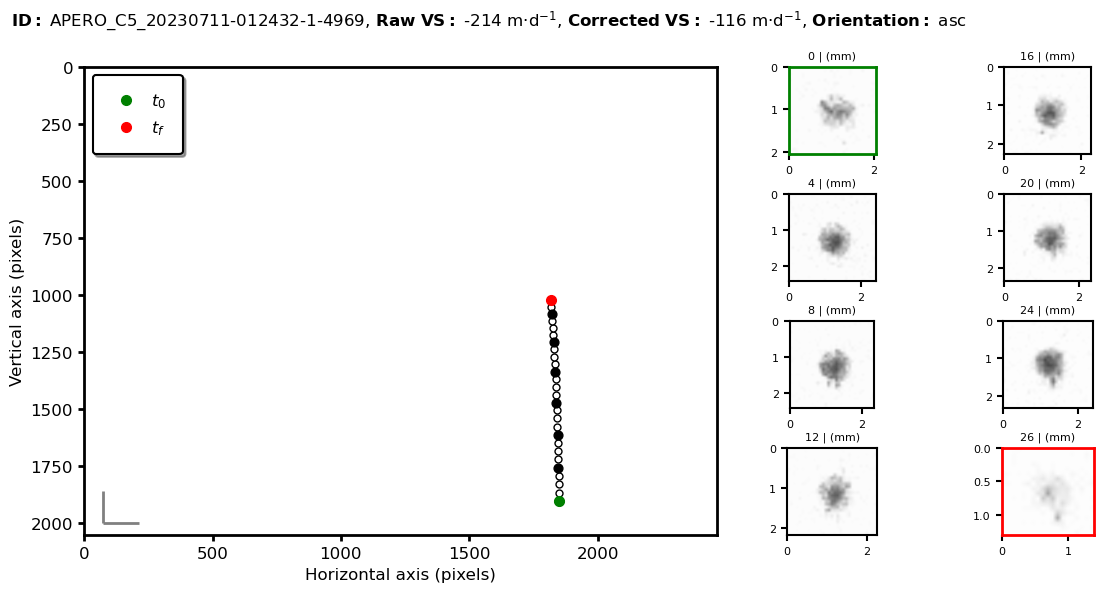

Process done for this sequence.
Delete images from local
Processing sequence 5/9: 20230711-044949
extract images from server to local
Processing track 0/1: APERO_C5_20230711-045228-1-2946


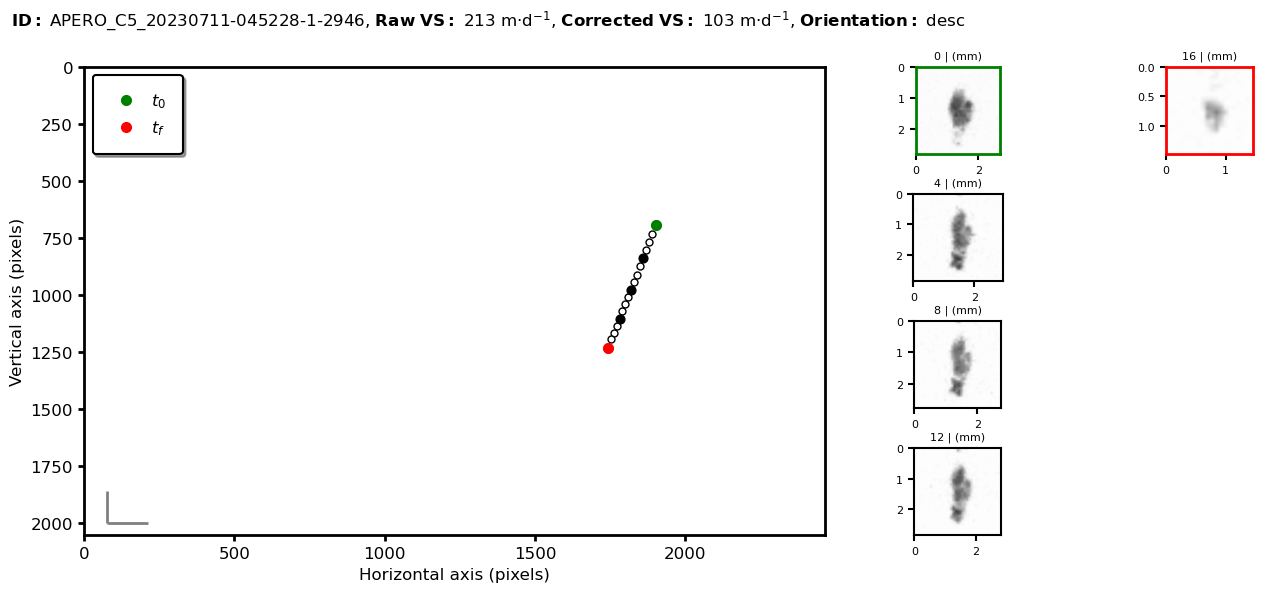

Process done for this sequence.
Delete images from local
Processing sequence 6/9: 20230712-115803
extract images from server to local
Processing track 0/2: APERO_C5_20230712-120258-1-9243


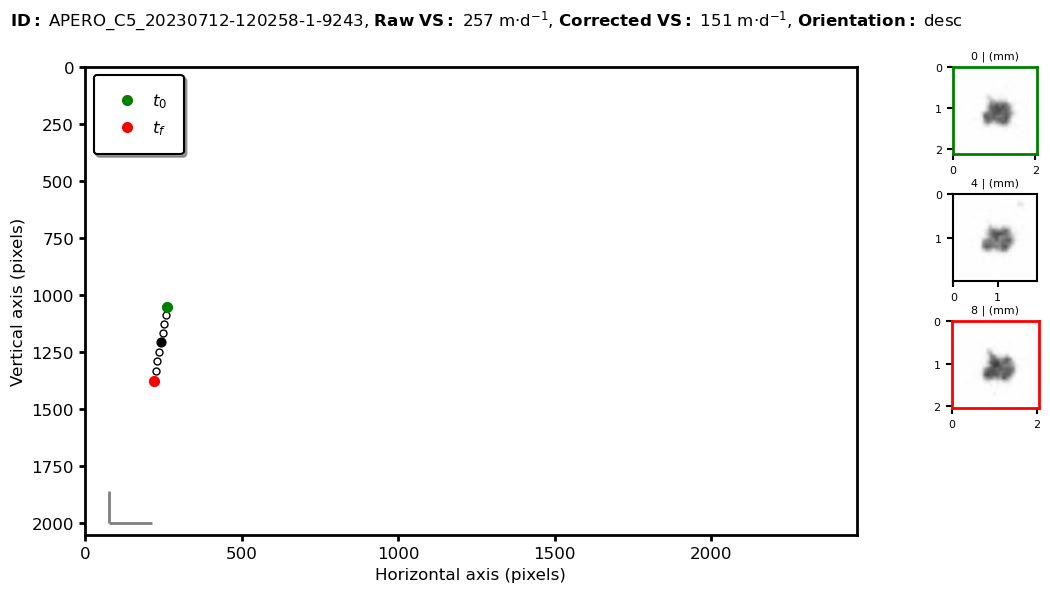

Processing track 0/2: APERO_C5_20230712-120305-1-9480


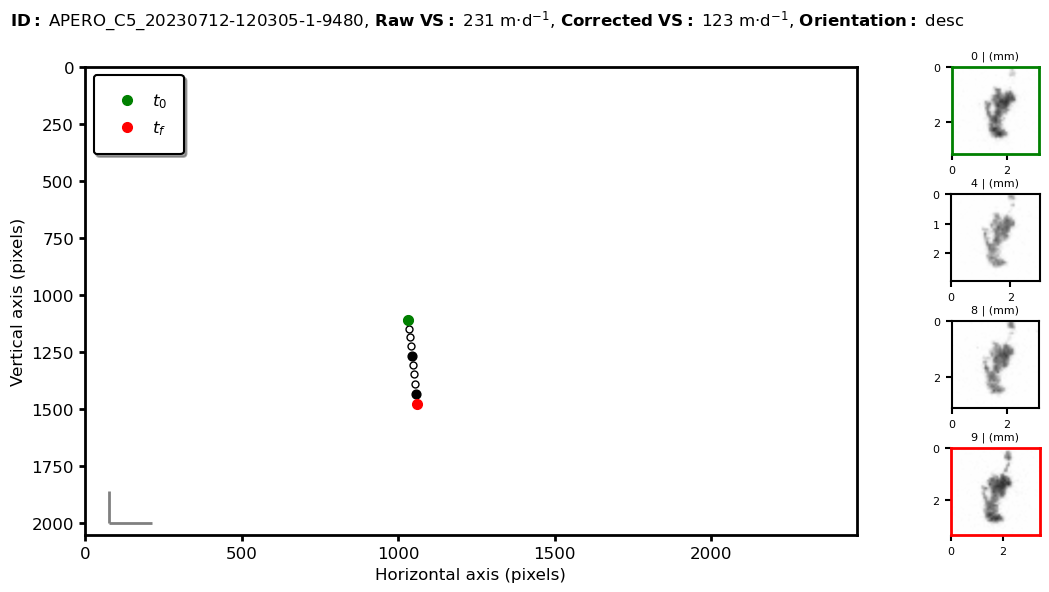

Process done for this sequence.
Delete images from local
Processing sequence 7/9: 20230712-141803
extract images from server to local
Processing track 0/3: APERO_C5_20230712-141905-1-1142


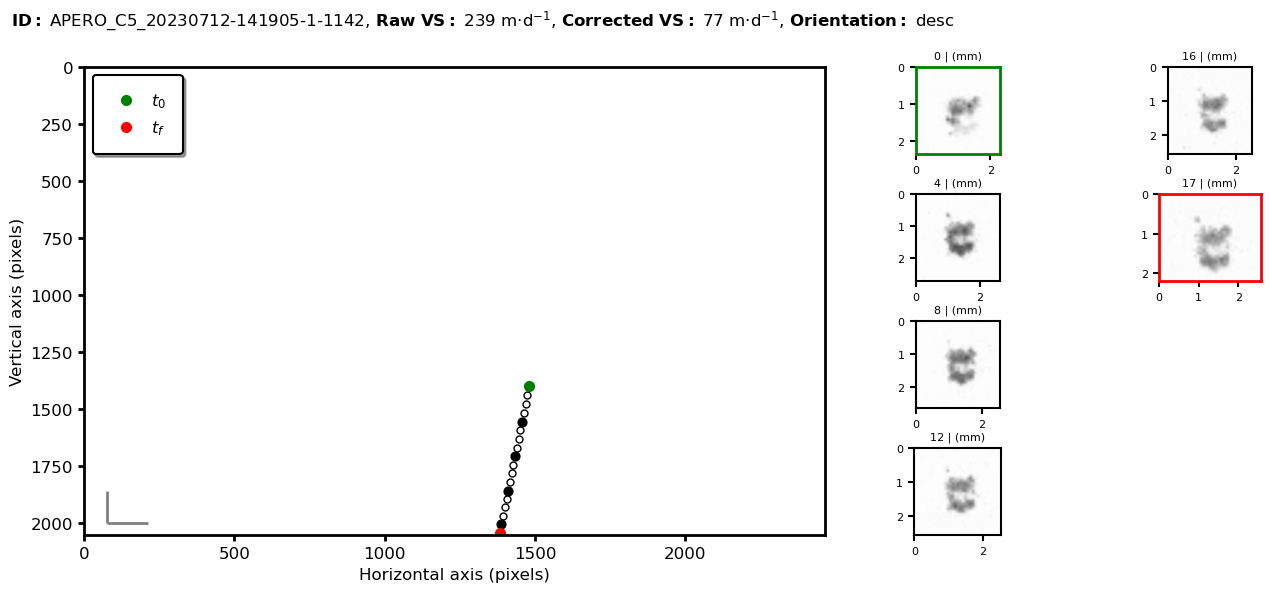

Processing track 0/3: APERO_C5_20230712-142050-1-4098


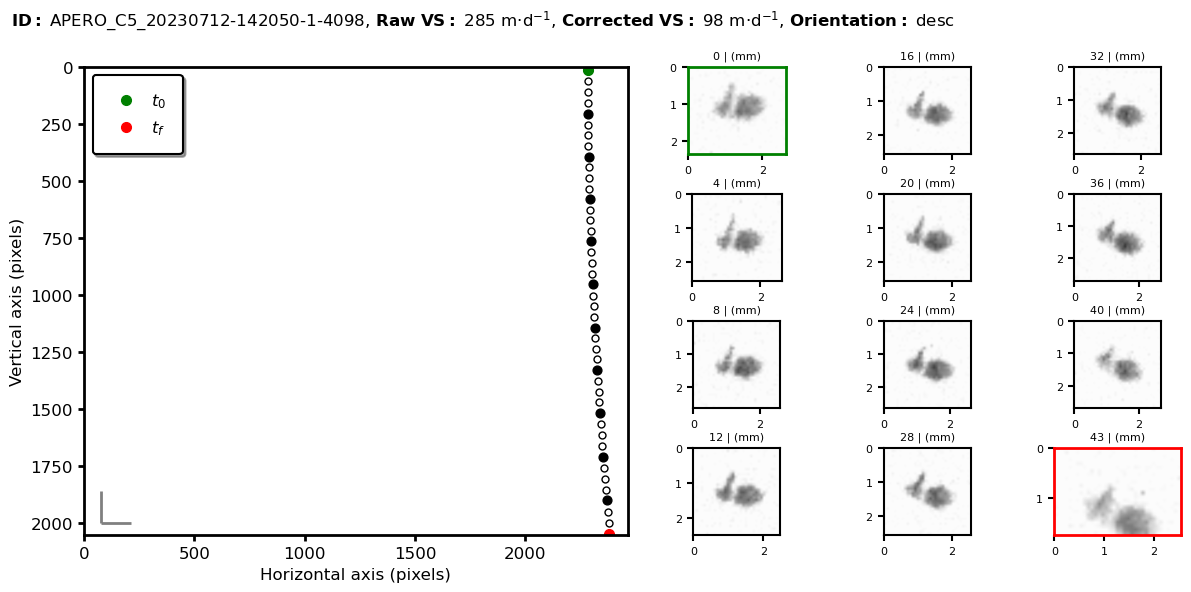

Processing track 0/3: APERO_C5_20230712-142447-1-11227


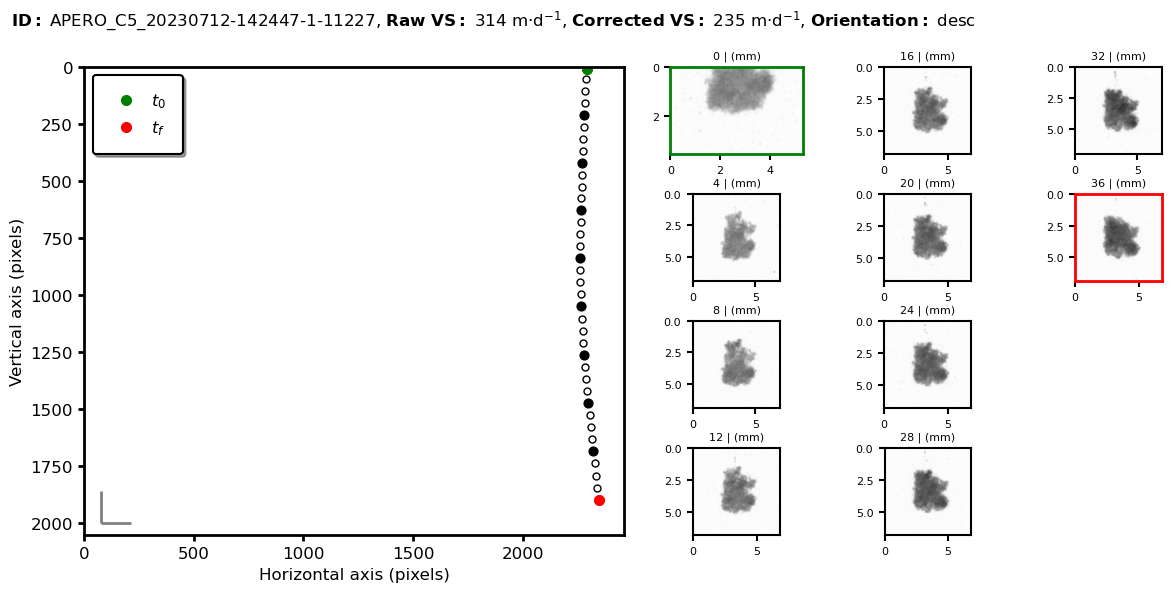

Process done for this sequence.
Delete images from local
Process done.


In [19]:
for sequence in sequences[1:5]:
    count_seq += 1
    print(f'Processing sequence {count_seq}/{total_sequences}: {sequence}')
    df_sequence = APERO_tracks[APERO_tracks['sequence'] == sequence]

    # extract images from server 
    sequence = df_sequence['sequence'].iloc[0]
    source_directory = '/home/aaccardo/plankton/_uvp6_missions_archives/uvp6_sn000146lp/uvp6_sn000146lp_2023_apero_float_cycle5'
    dir_raw = os.path.join(source_directory, 'raw')
    dest_directory = '/home/aaccardo/these_alex/Papers/Rising_stars/Track_plots'
    dir_copy_raw = os.path.join(dest_directory, 'copy_raw')

    # Define the path to the zip file that contains the raw images
    path_zip = os.path.join(dir_raw, sequence, 'images.zip')
    # Check if the path exists
    if os.path.exists(path_zip):
        # Extract the images
        archive = zipfile.ZipFile(path_zip)
        names = [i for i in archive.namelist() 
                 if not i.startswith('images')]
        print('extract images from server to local')
        for file in names:
            archive.extract(file, os.path.join(dir_copy_raw, sequence))
            
    # Define the list with track_id
    track_id = df_sequence['track_id'].unique().tolist()
    total_tracks = len(track_id)
    count_track = 0 
    
    # Loop over tracks
    for track in track_id:
        count_track += 1
        print(f'Processing track {count}/{total_tracks}: {track}')
    
        # Select the corresponding track from the summary dataframe
        data = df_sequence[df_sequence['track_id'] == track]
        #print(data)
    
        
        # Create the figure
        plot_track_and_vignettes_APERO(df_particles = data, disp_step = 4)
   
    print('Process done for this sequence.')
    # Delete the temporary copy raw folder
    print('Delete images from local')
    shutil.rmtree(os.path.join(dir_copy_raw, sequence))

print('Process done.')    

# Focus on a specific track 

In [36]:
test_df = APERO_tracks[APERO_tracks['track_id'] == 'APERO_C5_20230712-142447-1-11227']
test_df

,track_id,orientation_corrected,orientation_raw,vertical_speed,corrected_by_poly,esd_um,sequence,coord_x,coord_y,esd_px,filename,step_num
10423,APERO_C5_20230712-142447-1-11227,desc,desc,313.654738,234.96212,3366.873577,20230712-141803,2293.039568,11.798561,32.586528,/home/aaccardo/these_alex/Papers/Rising_stars/...,0
10424,APERO_C5_20230712-142447-1-11227,desc,desc,313.654738,234.96212,3366.873577,20230712-141803,2290.000644,52.733419,44.467303,/home/aaccardo/these_alex/Papers/Rising_stars/...,1
10425,APERO_C5_20230712-142447-1-11227,desc,desc,313.654738,234.96212,3366.873577,20230712-141803,2286.816472,107.049287,44.309540,/home/aaccardo/these_alex/Papers/Rising_stars/...,2
10426,APERO_C5_20230712-142447-1-11227,desc,desc,313.654738,234.96212,3366.873577,20230712-141803,2284.126220,159.707872,44.237644,/home/aaccardo/these_alex/Papers/Rising_stars/...,3
10427,APERO_C5_20230712-142447-1-11227,desc,desc,313.654738,234.96212,3366.873577,20230712-141803,2281.435591,212.110226,43.789254,/home/aaccardo/these_alex/Papers/Rising_stars/...,4
10428,APERO_C5_20230712-142447-1-11227,desc,desc,313.654738,234.96212,3366.873577,20230712-141803,2278.817581,264.235294,43.890904,/home/aaccardo/these_alex/Papers/Rising_stars/...,5
10429,APERO_C5_20230712-142447-1-11227,desc,desc,313.654738,234.96212,3366.873577,20230712-141803,2276.577252,317.910585,44.006788,/home/aaccardo/these_alex/Papers/Rising_stars/...,6
10430,APERO_C5_20230712-142447-1-11227,desc,desc,313.654738,234.96212,3366.873577,20230712-141803,2274.418000,370.162000,43.701937,/home/aaccardo/these_alex/Papers/Rising_stars/...,7
10431,APERO_C5_20230712-142447-1-11227,desc,desc,313.654738,234.96212,3366.873577,20230712-141803,2272.515111,421.728005,43.541402,/home/aaccardo/these_alex/Papers/Rising_stars/...,8
10432,APERO_C5_20230712-142447-1-11227,desc,desc,313.654738,234.96212,3366.873577,20230712-141803,2270.631935,473.387686,43.380273,/home/aaccardo/these_alex/Papers/Rising_stars/...,9


In [37]:
sequences = test_df['sequence'].unique().tolist()
total_sequences = len(sequences)
count_seq = 0 

Processing sequence 4/1: 20230712-141803
extract images from server to local
Processing track 1/1: APERO_C5_20230712-142447-1-11227


/tmp/ipykernel_927290/2970385027.py:210: UserWarning: The figure layout has changed to tight
  plt.tight_layout(h_pad=0.2)


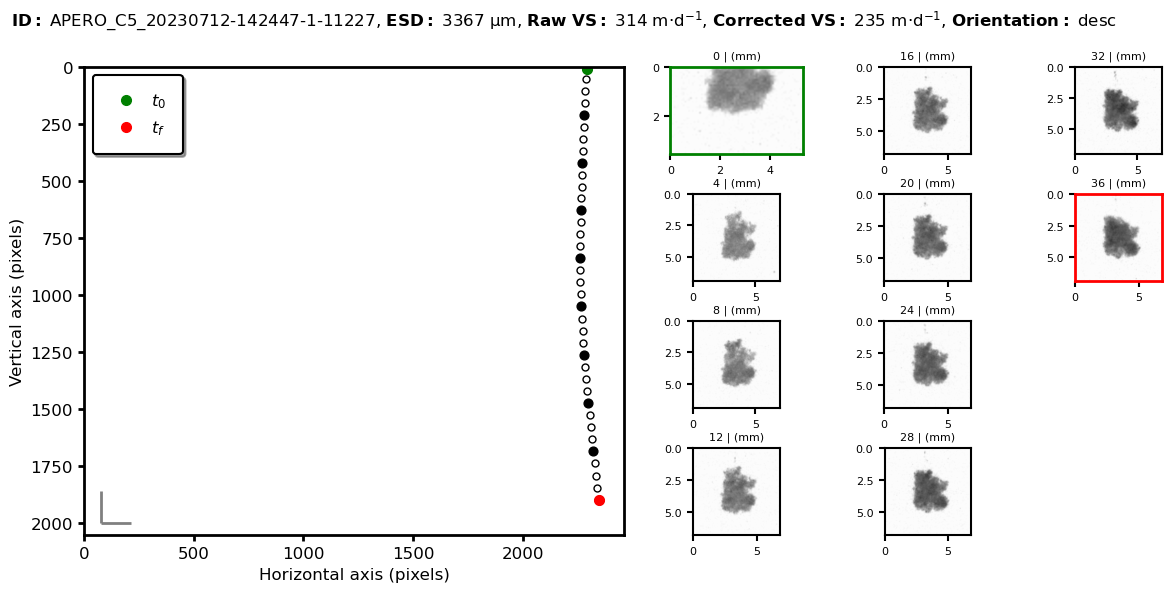

Process done for this sequence.
Delete images from local
Process done.


In [42]:
for sequence in sequences:
    count_seq += 1
    print(f'Processing sequence {count_seq}/{total_sequences}: {sequence}')
    df_sequence = test_df[test_df['sequence'] == sequence]

    # extract images from server 
    sequence = df_sequence['sequence'].iloc[0]
    source_directory = '/home/aaccardo/plankton/_uvp6_missions_archives/uvp6_sn000146lp/uvp6_sn000146lp_2023_apero_float_cycle5'
    dir_raw = os.path.join(source_directory, 'raw')
    dest_directory = '/home/aaccardo/these_alex/Papers/Rising_stars/Track_plots'
    dir_copy_raw = os.path.join(dest_directory, 'copy_raw')

    # Define the path to the zip file that contains the raw images
    path_zip = os.path.join(dir_raw, sequence, 'images.zip')
    # Check if the path exists
    if os.path.exists(path_zip):
        # Extract the images
        archive = zipfile.ZipFile(path_zip)
        names = [i for i in archive.namelist() 
                 if not i.startswith('images')]
        print('extract images from server to local')
        for file in names:
            archive.extract(file, os.path.join(dir_copy_raw, sequence))
            
    # Define the list with track_id
    track_id = df_sequence['track_id'].unique().tolist()
    total_tracks = len(track_id)
    count_track = 0 
    
    # Loop over tracks
    for track in track_id:
        count_track += 1
        print(f'Processing track {count_track}/{total_tracks}: {track}')
    
        # Select the corresponding track from the summary dataframe
        data = df_sequence[df_sequence['track_id'] == track]
        #print(data)
    
        
        # Create the figure
        plot_track_and_vignettes_APERO(df_particles = data, disp_step = 4, save_path='/home/aaccardo/these_alex/Papers/Rising_stars/Track_plots/Figures')
   
    print('Process done for this sequence.')
    # Delete the temporary copy raw folder
    print('Delete images from local')
    shutil.rmtree(os.path.join(dir_copy_raw, sequence))

print('Process done.')    